In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

In [31]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.shape

(64374, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [15]:
df.isnull().sum()

df.dropna(inplace=True) 
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")


CustomerID: 0 outliers
Age: 0 outliers
Tenure: 0 outliers
Usage Frequency: 0 outliers
Support Calls: 0 outliers
Payment Delay: 0 outliers
Total Spend: 0 outliers
Last Interaction: 0 outliers
Churn: 0 outliers


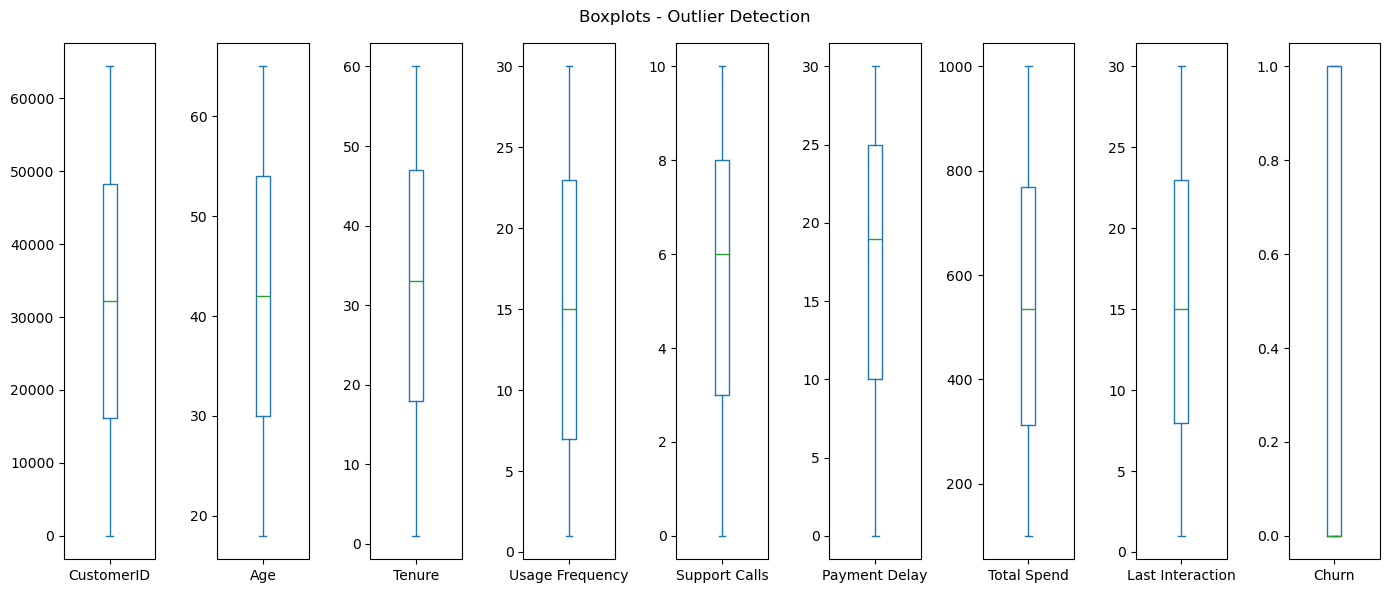

In [16]:
df[numeric_cols].plot(kind='box', figsize=(14, 6), subplots=True)
plt.suptitle("Boxplots - Outlier Detection")
plt.tight_layout()
plt.show()

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,32187.500000,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,41.970982,13.924911,18.0,30.00,42.0,54.00,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.00,33.0,47.00,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.00,15.0,23.00,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.00,6.0,8.00,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.00,19.0,25.00,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.00,534.0,768.00,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.00,15.0,23.00,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.00,0.0,1.00,1.0


/var/folders/kk/s6w8bx5n20907276dcq0wd1w0000gn/T/ipykernel_20898/2253658495.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df["Churn"], palette="Set1")


[Text(0, 0, '33881')]

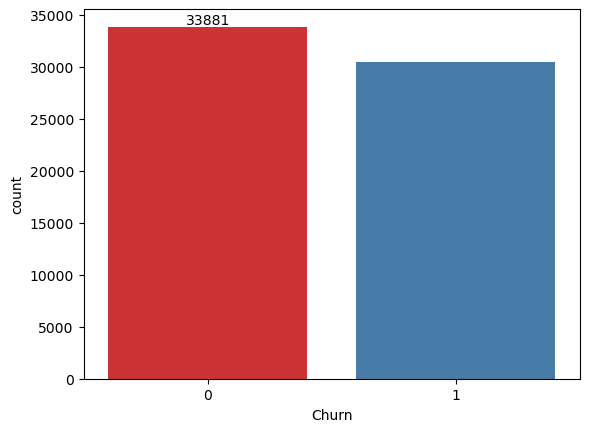

In [12]:
ax = sns.countplot(x=df["Churn"], palette="Set1")
ax.bar_label(ax.containers[0])

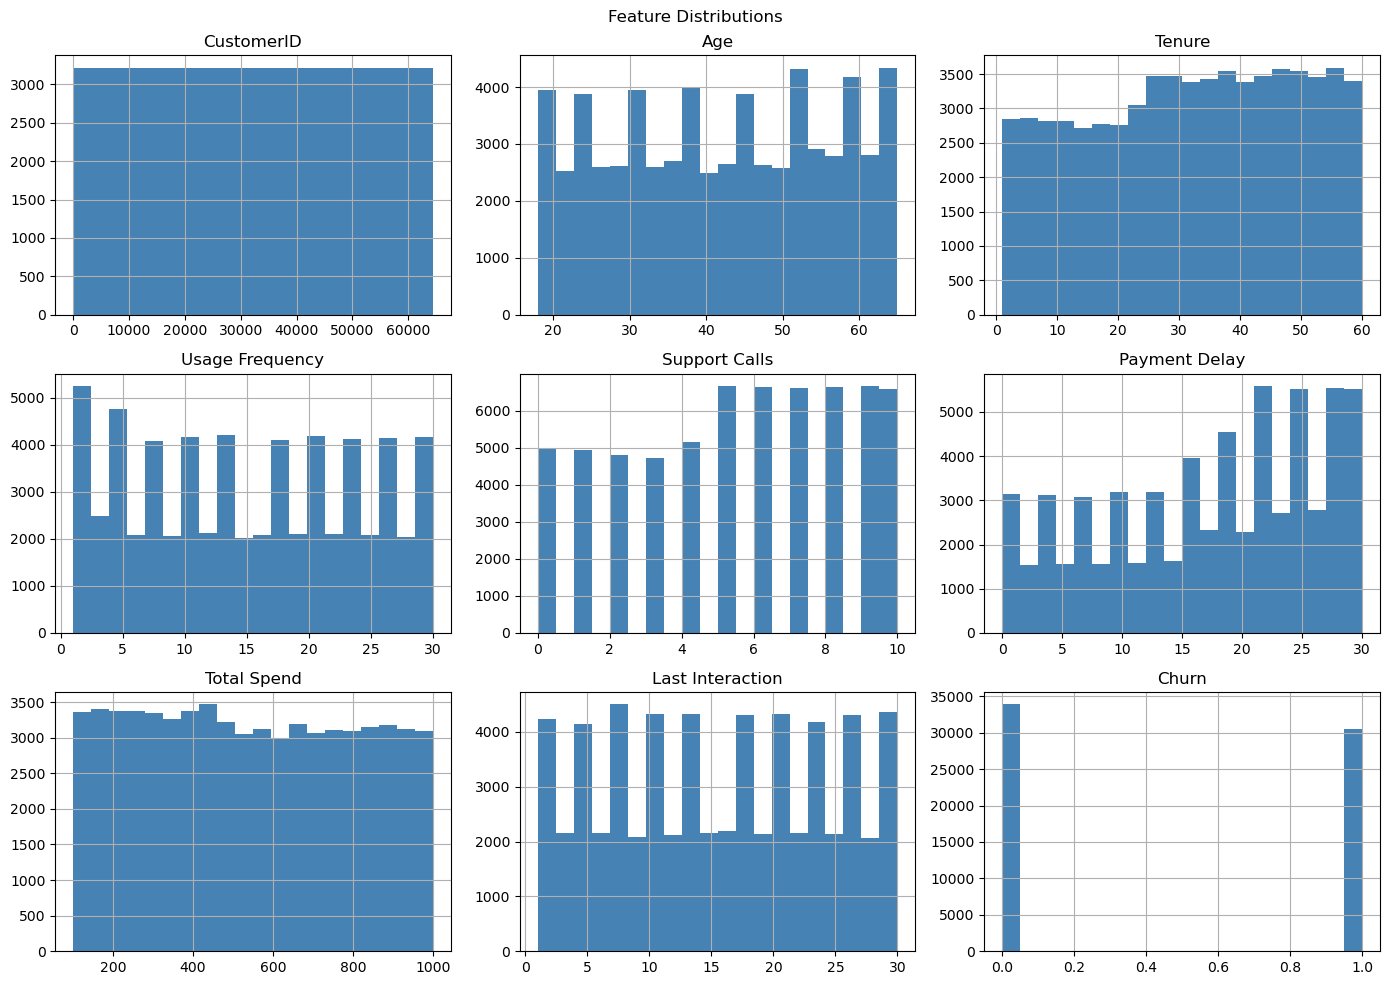

In [30]:
df[numeric_cols].hist(figsize=(14, 10), bins=20, color='steelblue')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()



In [21]:
num_data = df.select_dtypes(include = np.number)
correl = num_data.corr()
print(correl)

                  CustomerID       Age    Tenure  Usage Frequency  \
CustomerID          1.000000  0.043287  0.103296        -0.062699   
Age                 0.043287  1.000000 -0.007763        -0.038331   
Tenure              0.103296 -0.007763  1.000000         0.023485   
Usage Frequency    -0.062699 -0.038331  0.023485         1.000000   
Support Calls       0.164175  0.005014  0.060065        -0.014072   
Payment Delay       0.290684 -0.016132  0.055963         0.031132   
Total Spend        -0.037068  0.006490  0.009474         0.001527   
Last Interaction   -0.003718 -0.000148  0.005770        -0.009192   
Churn               0.529832  0.063457  0.195327        -0.115098   

                  Support Calls  Payment Delay  Total Spend  Last Interaction  \
CustomerID             0.164175       0.290684    -0.037068         -0.003718   
Age                    0.005014      -0.016132     0.006490         -0.000148   
Tenure                 0.060065       0.055963     0.009474       

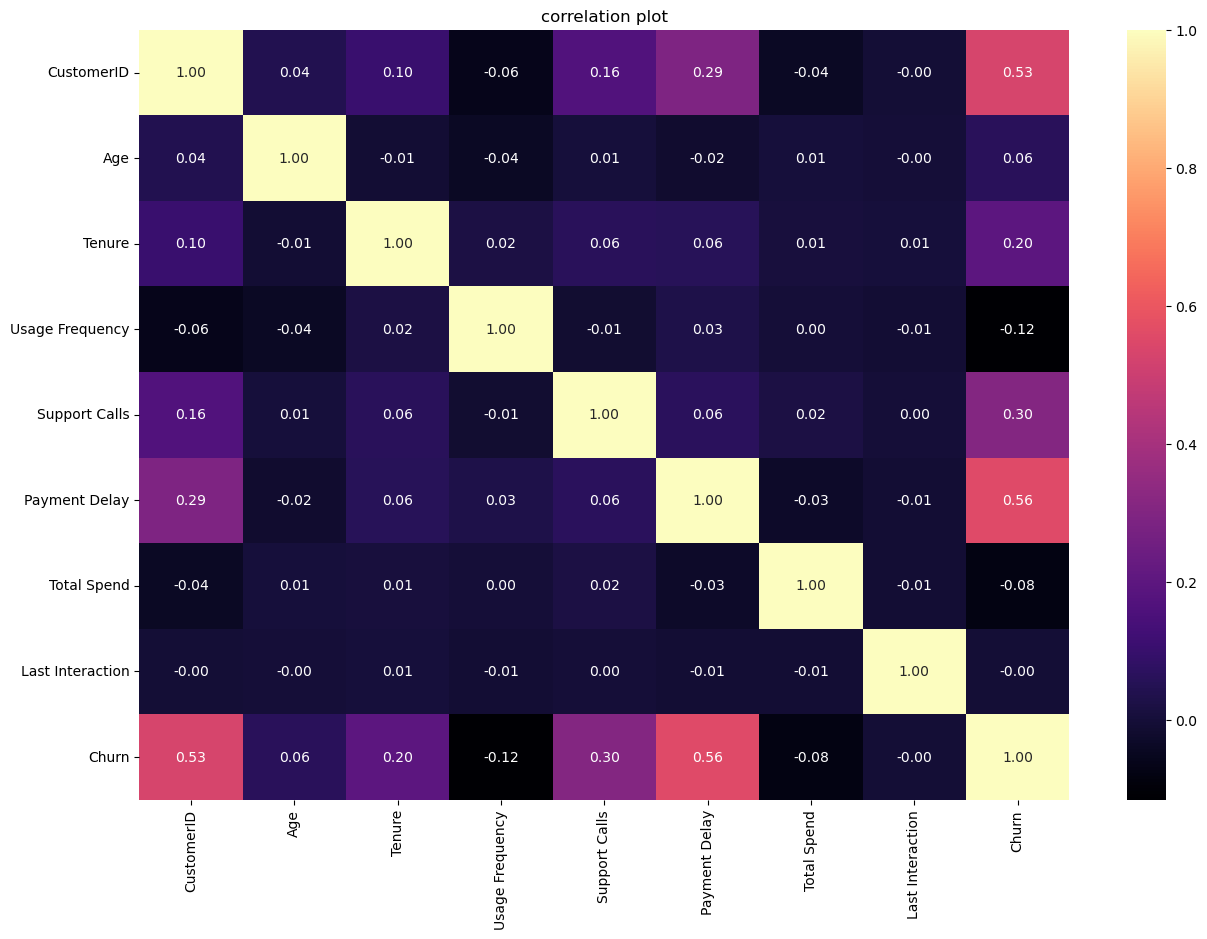

In [23]:
plt.figure(figsize=(15,10))
sns.heatmap(correl,annot = True, cmap = "magma" ,fmt = ".2f")
plt.title("correlation plot")
plt.show()

In [24]:
num_data = df.select_dtypes(include = np.number)
cov = num_data.cov()
print(cov)

                    CustomerID           Age        Tenure  Usage Frequency  \
CustomerID        3.453397e+08  11201.493359  32821.432891    -10272.542347   
Age               1.120149e+04    193.903155     -1.848394        -4.705795   
Tenure            3.282143e+04     -1.848394    292.349607         3.540253   
Usage Frequency  -1.027254e+04     -4.705795      3.540253        77.730144   
Support Calls     9.500595e+03      0.217397      3.198102        -0.386351   
Payment Delay     4.781856e+04     -1.988501      8.470440         2.429701   
Total Spend      -1.797036e+05     23.576122     42.258972         3.512843   
Last Interaction -5.968473e+02     -0.017758      0.852269        -0.700069   
Churn             4.916229e+03      0.441207      1.667574        -0.506681   

                  Support Calls  Payment Delay    Total Spend  \
CustomerID          9500.594504   47818.558518 -179703.618217   
Age                    0.217397      -1.988501      23.576122   
Tenure        

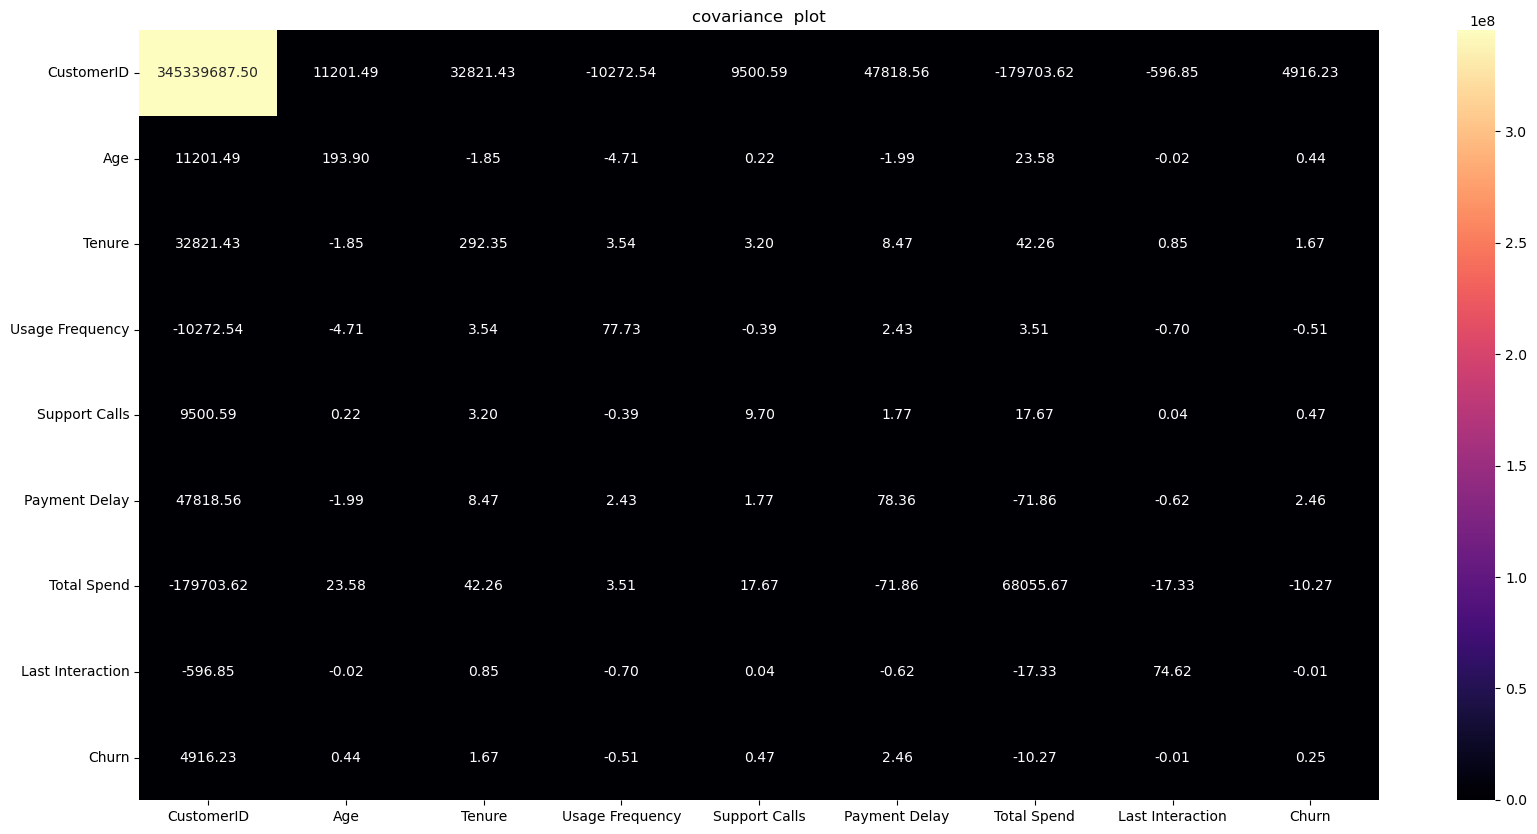

In [28]:
plt.figure(figsize = (20,10))
sns.heatmap(cov,annot = True, cmap = "magma" ,fmt = ".2f")
plt.title("covariance  plot")
plt.show()

In [32]:
df.drop(columns=['CustomerID'], inplace=True)

In [33]:
X = df.drop(columns=['Churn'])  
y = df['Churn']        
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn value counts:\n", y.value_counts())

Features shape: (64374, 10)
Target shape: (64374,)
Churn value counts:
 Churn
0    33881
1    30493
Name: count, dtype: int64


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 51499
Testing samples:  12875


In [41]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)  

In [42]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=5000),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                 : SVC(),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5)
}


In [43]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy])

    print("\n" + "="*50)
    print(f"  {name}")
    print("="*50)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


  Logistic Regression
Accuracy: 0.8306

Confusion Matrix:
[[5639 1154]
 [1027 5055]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6793
           1       0.81      0.83      0.82      6082

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875


  Decision Tree
Accuracy: 0.9988

Confusion Matrix:
[[6786    7]
 [   8 6074]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875


  Random Forest
Accuracy: 0.9995

Confusion Matrix:
[[6792    1]
 [   5 6077]]

Classification Report:
              precision    r

In [44]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n===== MODEL COMPARISON =====")
print(results_df.sort_values(by="Accuracy", ascending=False).to_string(index=False))



===== MODEL COMPARISON =====
              Model  Accuracy
      Random Forest  0.999534
      Decision Tree  0.998835
                SVM  0.943379
                KNN  0.910214
Logistic Regression  0.830602
